> **Superseded** by `jevqu_c4_llm_taxonomy.ipynb`. The saved outputs below predate two fixes: children are now used at query time only under a confident parent (so queries and item labels agree), and plain, boosted and filtered searches now share one query path (RRF ties broke differently before, biasing boost results by 0.25 to 0.9 nDCG points). Kept as the record of the collection-words naming run.


# Taxonomy induction on Amazon-C4, from the items alone: two levels

jevqu builds the taxonomy itself. `create_query_understanding` sees only the collection, never a query:

1. **Parents.** Cluster a 5,000-item sample into 20 groups (k-means on the stored embeddings) and name each one. The encoder (bge-small) ranks 8 candidate names taken from the group's own text, its most distinctive and its most widespread phrases. Jev picks one after seeing 10 diverse members. The pick stands if Jev places at least 40% of 15 random members under it; otherwise the best-fitting candidate is used, or the group gets no class. A name that more than 15% of other groups' items fit is never used. Jev then scores every sampled item against every named class: a class is kept if it covers 0.5% to 40% of items, and of two classes Jev accepts for mostly the same items only the bigger one stays.
2. **Children.** The same sample is clustered into 80 finer groups and named the same way. Each finer class goes under the parent that holds at least half its items and is scored only on that parent's items, as labeling will do. A finer class that no parent holds becomes a top-level class itself.

All 20,000 items are then labeled (a child only for items in its parent) and the result is scored on 300 held-out queries. At query time Jev reads each query once against every class, parents and children together. The baselines are plain hybrid search and Amazon's own departments (+3.9 nDCG@10, tuned on the same queries, from `jevqu_c4_demo.ipynb`). Step 3 also reports how often a filter fired, how often it kept the target item (a filter pays off only above about 85%), and the change split by whether the target item got any class.

**Cost**, about $3.50 to $4: naming about $0.20 (cached by earlier runs), step 1 coverage about $0.80, step 2 labeling about $2.50 to $3, step 3 a few cents. Step 1 prices the parents' coverage on a small uncached pilot and step 2 prices labeling the same way; each stops if its extrapolated cost exceeds `JEVQU_MAX_USD` (default $10).


In [1]:
import csv, dataclasses, json, os, random, sys, tempfile, time, urllib.request, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")        # tqdm without ipywidgets
warnings.filterwarnings("ignore", message="Payload indexes have no effect")  # in-memory Qdrant only

import matplotlib.pyplot as plt
import numpy as np
from fastembed import SparseTextEmbedding, TextEmbedding
from IPython.display import Markdown, display
from qdrant_client import QdrantClient, models

ROOT = Path.cwd() if (Path.cwd() / "jevqu").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
for line in (ROOT / ".env").read_text().splitlines() if (ROOT / ".env").exists() else []:
    key, _, value = line.partition("=")
    if key.strip() and not key.lstrip().startswith("#"):
        os.environ.setdefault(key.strip(), value.strip().strip("'\""))

from jevqu import JEV_MODEL
from jevqu.api import _sample, create_query_understanding, set_query_understanding, understand_query, upload_points
from jevqu.classify import classify_point
from jevqu.induce import bge_small, coverage, propose
from jevqu.jev import Jev
from jevqu.metrics import ndcg_at_k, paired_bootstrap, recall_at_k
from jevqu.qquery import build_filter, run
from jevqu.schema import Taxonomy, Thresholds, Understanding
from jevqu.text import state_from_payload

SEED = 0
N_QUERIES = 300           # evaluation queries: used only in step 3, never during induction
N_POINTS = 20_000         # the same collection as jevqu_c4_demo.ipynb
SAMPLE = 5_000            # items create_query_understanding looks at
K = 20                    # parent groups
CHILD_K = 80              # finer groups for the second level
USE_JEV = bool(os.environ.get("OPENROUTER_API_KEY"))
MAX_USD = float(os.environ.get("JEVQU_MAX_USD", "10"))
WORKERS = 8
DATA = ROOT / "data" / "c4"
COLLECTION = "c4-induced"
REFERENCE = {"filter every guess": (0.039, 0.022, 0.055), "jevqu auto": (0.013, 0.005, 0.021)}  # Amazon's departments, Jev run
print("classifier:", f"Jev ({JEV_MODEL}) on OpenRouter" if USE_JEV else "offline stand-in (no OPENROUTER_API_KEY)")

classifier: Jev (typesafe/jev-1.13) on OpenRouter


## 1. The collection

The same 300 queries and 20,000 items as the department demo: each query's target item plus a uniform sample of C4's 1M-item pool. Items carry only their text; Amazon's department is used only to describe the classes afterwards.

In [2]:
BASE = "https://huggingface.co/datasets/McAuley-Lab/Amazon-C4/resolve/main/"
DATA.mkdir(parents=True, exist_ok=True)
csv.field_size_limit(sys.maxsize)
for local, remote in [("test.csv", "test.csv"), ("items.jsonl", "sampled_item_metadata_1M.jsonl")]:
    if not (DATA / local).exists():
        urllib.request.urlretrieve(BASE + remote, DATA / local)

rng = random.Random(SEED)
with open(DATA / "test.csv", newline="") as f:
    c4_queries = list(csv.DictReader(f))
evalq = rng.sample(c4_queries, N_QUERIES)
targets = {q["item_id"] for q in evalq}
items, pool, seen = {}, [], 0
with open(DATA / "items.jsonl") as f:
    for line in f:
        d = json.loads(line)
        if d["item_id"] in targets:
            items[d["item_id"]] = d
            continue
        seen += 1
        if len(pool) < N_POINTS:
            pool.append(d)
        elif (j := rng.randrange(seen)) < N_POINTS:
            pool[j] = d
for d in pool[: N_POINTS - len(items)]:
    items[d["item_id"]] = d
catalog = list(items.values())
pid = {d["item_id"]: n for n, d in enumerate(catalog)}
qtexts = [q["query"] for q in evalq]
relevant = [{pid[q["item_id"]]} for q in evalq]

def text(d):
    return d["metadata"][:600]

def title(d):
    return d["metadata"].split(". ")[0][:80]

def sparse_vec(s):
    return models.SparseVector(indices=s.indices.tolist(), values=s.values.tolist())

dense, bm25 = TextEmbedding("BAAI/bge-small-en-v1.5"), SparseTextEmbedding("Qdrant/bm25")
cache = DATA / f"dense_{SEED}_{N_QUERIES}_{N_POINTS}.npy"
if cache.exists():
    dvecs = np.load(cache)
else:
    dvecs = np.array(list(dense.embed([text(d) for d in catalog], batch_size=64)))
    np.save(cache, dvecs)
svecs = list(bm25.embed([text(d) for d in catalog]))

client = QdrantClient(url=os.environ["QDRANT_URL"]) if os.environ.get("QDRANT_URL") else QdrantClient(":memory:")
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)
client.create_collection(COLLECTION,
    vectors_config={"dense": models.VectorParams(size=dvecs.shape[1], distance=models.Distance.COSINE)},
    sparse_vectors_config={"sparse": models.SparseVectorParams(modifier=models.Modifier.IDF)})
points = [models.PointStruct(id=pid[d["item_id"]], vector={"dense": v.tolist(), "sparse": sparse_vec(s)},
                             payload={"item_id": d["item_id"], "text": text(d)})
          for d, v, s in zip(catalog, dvecs, svecs)]
client.upsert(COLLECTION, points)
print(f"{len(points):,} items indexed, {len(evalq)} evaluation queries")

20,000 items indexed, 300 evaluation queries


## 2. The classifier

With a key, Jev (`typesafe/jev-1.13`) through OpenRouter. Without one, a word-matching stand-in that only proves the notebook runs: its numbers mean nothing.

In [3]:
class OfflineStandIn:
    # Says yes when words of the class name appear in the text. Only for checking that the notebook runs.
    model = "offline"

    def ask(self, state, questions):
        blob = json.dumps(state).lower()
        out = {}
        for qid, q in questions.items():
            if q["type"] == "choice":  # class naming: take the encoder's top option
                out[qid] = {"type": "choice", "choice": next(iter(q["criteria"])), "confidence": 0.9}
                continue
            words = q["instructions"].split("`")[1].lower().split() if "`" in q["instructions"] else None
            hits = sum(w in blob for w in words) if words else 0
            p = 0.6 if words is None else 0.95 if hits >= 2 else 0.7 if hits == 1 else 0.05
            out[qid] = {"type": "noul", "noul": p}
        return out

jev = Jev(cache_dir=ROOT / ".jev_cache") if USE_JEV else OfflineStandIn()

def spent():
    return sum(getattr(jev, "usage", []))

def price_check(label, pilot_fn, n_pilot, n_total):
    # prices n_pilot fresh (uncached) requests and stops before a run above MAX_USD
    if not USE_JEV:
        return
    with tempfile.TemporaryDirectory() as d:
        fresh = Jev(cache_dir=d)
        pilot_fn(fresh)
    estimate = sum(fresh.usage) / n_pilot * n_total
    print(f"{label}: about ${estimate:.2f} for {n_total:,} requests (pilot of {n_pilot}, upper bound: cached answers are free)")
    assert estimate <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD:.0f}"

## 3. Step 1: induce the taxonomy

The parents are named first, then the price check prices 10 of the 5,000 parent coverage requests. `create_query_understanding` reuses those cached answers and adds the second level.


In [4]:
pts = _sample(client, COLLECTION, SAMPLE)
states = [state_from_payload(p.payload) for p in pts]
texts = [" ".join(str(v) for v in st.values() if isinstance(v, str)) for st in states]
encoder = bge_small()
t0, s0 = time.time(), spent()
cands = propose(texts, np.array([p.vector["dense"] for p in pts]), states, jev, encoder, k=K, workers=WORKERS)
print(f"{len(cands)} named parent classes from {K} groups in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))
print(", ".join(c.name for c in cands))
price_check("step 1, parent coverage", lambda fresh: coverage(cands, states[:10], fresh, workers=WORKERS), 10, SAMPLE)

t0, s0 = time.time(), spent()
tax, report = create_query_understanding(client, COLLECTION, jev, sample=SAMPLE, k=K, child_k=CHILD_K, workers=WORKERS,
                                         encoder=encoder)
level1, kids = tax.level1(), [c for c in tax.classes if c.parent]
print(f"{len(level1)} top-level classes ({sum(bool(r.get('promoted')) and r['kept'] for r in report)} of them promoted "
      f"finer classes) and {len(kids)} children, in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))
assert spent() <= MAX_USD, f"step 1 spent more than JEVQU_MAX_USD=${MAX_USD:.0f}"


15 named parent classes from 20 groups in 2s, $0.0000
Soft, Casual, Protective, Pet, Tool, Natural, Shoes, Replacement, Decor, Book, Music, Kitchen, Toys, Decoration, Storage
step 1, parent coverage: about $0.26 for 5,000 requests (pilot of 10, upper bound: cached answers are free)
36 top-level classes (22 of them promoted finer classes) and 22 children, in 12s, $0.0000


In [5]:
name_of = {r["id"]: r["name"] for r in report}
rows = ["| class | level | parent | coverage of the sample | kept, or why not |", "|---|---|---|---|---|"]
for r in sorted(report, key=lambda r: (r.get("parent") is not None, name_of.get(r.get("parent"), ""), -r["coverage"])):
    level = "child" if r.get("parent") else "top (promoted)" if r.get("promoted") else "top"
    rows.append(f"| {r['name']} | {level} | {name_of.get(r.get('parent'), '')} | {r['coverage']:.1%} | "
                f"{'kept' if r['kept'] else r['rejected_by']} |")
display(Markdown("\n".join(rows)))


| class | level | parent | coverage of the sample | kept, or why not |
|---|---|---|---|---|
| Soft | top |  | 18.7% | kept |
| Decoration | top |  | 14.7% | kept |
| Casual | top |  | 14.3% | kept |
| Decor | top |  | 12.8% | duplicates decoration |
| Holds | top (promoted) |  | 12.0% | kept |
| Protective | top |  | 10.6% | kept |
| Replacement | top |  | 9.9% | kept |
| Book | top |  | 8.5% | kept |
| Kitchen | top |  | 8.5% | kept |
| Natural | top |  | 7.4% | kept |
| Tool | top |  | 6.7% | kept |
| Gift | top (promoted) |  | 6.5% | kept |
| Storage | top |  | 5.9% | kept |
| Athletic | top (promoted) |  | 5.5% | kept |
| Toys | top |  | 4.6% | kept |
| Pet | top |  | 4.2% | kept |
| Shoes | top |  | 4.1% | kept |
| Lighting | top (promoted) |  | 2.8% | kept |
| Delicious | top (promoted) |  | 2.5% | kept |
| Hair | top (promoted) |  | 2.5% | kept |
| Audio | top (promoted) |  | 2.4% | kept |
| Skin | top (promoted) |  | 2.0% | kept |
| Music | top |  | 1.9% | kept |
| Strips | top (promoted) |  | 1.6% | kept |
| Supplement | top (promoted) |  | 1.5% | kept |
| Game | top (promoted) |  | 1.4% | kept |
| Japanese Style | top (promoted) |  | 1.4% | kept |
| Control Fit | top (promoted) |  | 1.4% | kept |
| Fragrance | top (promoted) |  | 1.3% | kept |
| Makeup | top (promoted) |  | 1.3% | kept |
| Bed | top (promoted) |  | 1.3% | kept |
| Cable | top (promoted) |  | 1.0% | kept |
| Pain Relief | top (promoted) |  | 0.8% | kept |
| Dress | top (promoted) |  | 0.8% | kept |
| Mounting Bracket | top (promoted) |  | 0.7% | kept |
| Timepiece | top (promoted) |  | 0.7% | kept |
| Virtual | top (promoted) |  | 0.6% | kept |
| Men | child | Casual | 2.7% | kept |
| Shirt | child | Casual | 2.4% | kept |
| Furniture | child | Casual | 0.9% | kept |
| Decor | child | Decoration | 11.0% | kept |
| Party Supplies | child | Decoration | 2.5% | kept |
| Wall Decor | child | Decoration | 2.4% | kept |
| Jewelry | child | Decoration | 2.1% | kept |
| Outdoor | child | Decoration | 1.8% | kept |
| Christmas Decoration | child | Decoration | 1.5% | kept |
| Sticker | child | Decoration | 1.0% | kept |
| Curtain | child | Decoration | 0.7% | kept |
| Nail | child | Decoration | 0.4% | size |
| Container | child | Kitchen | 2.5% | kept |
| Food | child | Natural | 1.9% | kept |
| Gluten Free | child | Natural | 1.6% | duplicates food |
| Plant | child | Natural | 1.2% | kept |
| Cover | child | Protective | 5.8% | kept |
| Glasses | child | Protective | 0.4% | size |
| Car | child | Replacement | 1.0% | kept |
| Battery | child | Replacement | 0.5% | kept |
| Footwear | child | Shoes | 4.0% | same as parent |
| Bedding | child | Soft | 1.9% | kept |
| Boys Girls | child | Soft | 1.6% | kept |
| Costume | child | Soft | 0.4% | size |
| Holder | child | Storage | 3.1% | kept |
| Organizer | child | Storage | 2.7% | duplicates holder |
| Bag | child | Storage | 1.4% | kept |
| Brush | child | Tool | 0.6% | kept |

## 4. Step 2: label the collection

One request per item asks every top-level class; a second asks the children of the parents the item was placed in.


In [6]:
if not tax.classes:
    raise SystemExit("no classes kept: nothing to label or evaluate")
set_query_understanding(client, COLLECTION, tax)
price_check("step 2, labeling",
            lambda fresh: [classify_point(p.payload, tax, fresh) for p in points[:25]], 25, len(points))
t0, s0 = time.time(), spent()
failed = upload_points(client, COLLECTION, points, jev, workers=WORKERS)
print(f"labeled {len(points) - len(failed):,} items with {len(tax.classes)} classes in {time.time() - t0:.0f}s, "
      f"{len(failed)} failed" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))
stored = {pt.id: pt.payload for pt in client.scroll(COLLECTION, limit=len(points), with_payload=["classes"])[0]}
n_labels = Counter(len(stored[i].get("classes") or []) for i in stored)
print("labels per item:", dict(sorted(n_labels.items())),
      f"| items with any class: {np.mean([bool(stored[i].get('classes')) for i in stored]):.0%}")


step 2, labeling: about $2.43 for 20,000 requests (pilot of 25, upper bound: cached answers are free)
labeled 20,000 items with 58 classes in 6s, 0 failed, $0.0000
labels per item: {0: 1549, 1: 5533, 2: 5391, 3: 3761, 4: 2472, 5: 904, 6: 281, 7: 83, 8: 22, 9: 4} | items with any class: 92%


## 5. Step 3: score on the 300 held-out queries

Jev reads each query once, against every class. Strategies: jevqu's default gates (filter at P ≥ 0.9, boost at 0.6 to 0.9), a filter on every guess (P ≥ 0.5), and the default gates with the top-level classes only, to show what the children add.


In [7]:
t0, s0 = time.time(), spent()
with ThreadPoolExecutor(WORKERS) as ex:
    us = list(ex.map(lambda q: understand_query(client, COLLECTION, q, jev), qtexts))
qd = [d.tolist() for d in dense.embed(qtexts)]
qs = [sparse_vec(s) for s in bm25.embed(qtexts)]
print(f"understood {len(us)} queries in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))

def only(understood, ids):
    return [Understanding([(c, p) for c, p in u.classes if c in ids], u.facets, u.taxonomy_version) for u in understood]

def ranked(mode, thresholds, understood):
    t = dataclasses.replace(tax, thresholds=thresholds)
    return [[h.id for h in run(client, COLLECTION, d, s, None if mode == "off" else u, t, limit=20, mode=mode)]
            for d, s, u in zip(qd, qs, understood)]

def scores(r):
    return ([ndcg_at_k(x, rel, 10) for x, rel in zip(r, relevant)], [recall_at_k(x, rel, 20) for x, rel in zip(r, relevant)])

base = ranked("off", Thresholds(), us)
base_ndcg, base_rec = scores(base)
results, rows = {}, ["| strategy | classes | nDCG@10 | change (95% CI) | recall@20 | queries changed |", "|---|---|---|---|---|---|",
                     f"| hybrid search | 0 | {np.mean(base_ndcg):.4f} | | {np.mean(base_rec):.4f} | 0% |"]
top_ids = {c.id for c in level1}
for sname, mode, thr, understood, n_cls in [
        ("jevqu auto", "auto", Thresholds(), us, len(tax.classes)),
        ("filter every guess", "filter", Thresholds(filter_above=0.5), us, len(tax.classes)),
        ("jevqu auto, top-level classes only", "auto", Thresholds(), only(us, top_ids), len(top_ids))]:
    r = ranked(mode, thr, understood)
    nd, rc = scores(r)
    d, lo, hi = paired_bootstrap(base_ndcg, nd)
    results[sname] = {"change": d, "ci": (lo, hi), "ndcg10": float(np.mean(nd)), "recall20": float(np.mean(rc))}
    changed = np.mean([a != b for a, b in zip(r, base)])
    rows.append(f"| {sname} | {n_cls} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc):.4f} | {changed:.0%} |")
for sname, (d, lo, hi) in REFERENCE.items():
    rows.append(f"| reference: Amazon's 31 departments, {sname} | 31 | | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | | |")
display(Markdown("\n".join(rows)))

understood 300 queries in 50s, $0.0501


| strategy | classes | nDCG@10 | change (95% CI) | recall@20 | queries changed |
|---|---|---|---|---|---|
| hybrid search | 0 | 0.2957 | | 0.5333 | 0% |
| jevqu auto | 58 | 0.2887 | -0.0070 (-0.0255 to +0.0112) | 0.4967 | 77% |
| filter every guess | 58 | 0.2493 | -0.0464 (-0.0752 to -0.0167) | 0.4600 | 72% |
| jevqu auto, top-level classes only | 36 | 0.2973 | +0.0016 (-0.0085 to +0.0113) | 0.5300 | 70% |
| reference: Amazon's 31 departments, filter every guess | 31 | | +0.0390 (+0.0220 to +0.0550) | | |
| reference: Amazon's 31 departments, jevqu auto | 31 | | +0.0130 (+0.0050 to +0.0210) | | |

### How the filters behaved (jevqu auto, all classes)

A wrong filter removes the target item (about -25 points on that query); a right one moves it up a few ranks. So what matters is how often a filter fires, how often it is right, and whether the target item has a class at all.


In [8]:
auto_ndcg, _ = scores(ranked("auto", Thresholds(), us))
delta = 100 * (np.array(auto_ndcg) - np.array(base_ndcg))
tgt = [next(iter(rel)) for rel in relevant]
fired = [[c for c, p in u.classes if p >= tax.thresholds.filter_above] for u in us]
right = np.array([bool(f) and all(c in (stored[t].get("classes") or []) for c in f) for f, t in zip(fired, tgt)])
wrong = np.array([bool(f) for f in fired]) & ~right
labeled = np.array([bool(stored[t].get("classes")) for t in tgt])
mean = lambda m: f"{delta[m].mean():+.2f}" if m.any() else "n/a"
n_f = int(right.sum() + wrong.sum())
print(f"filters fired on {n_f} of {len(us)} queries ({n_f / len(us):.0%}), kept the target on {right.sum()} "
      f"({right.sum() / max(1, n_f):.0%}; break-even about 85%)")
print(f"change per right filter {mean(right)} pts, per wrong filter {mean(wrong)} pts")
print(f"target items with any class: {labeled.mean():.0%}; change on those queries {mean(labeled)}, on the rest {mean(~labeled)} pts")


filters fired on 155 of 300 queries (52%), kept the target on 120 (77%; break-even about 85%)
change per right filter +4.75 pts, per wrong filter -21.30 pts
target items with any class: 91%; change on those queries -0.40, on the rest -3.57 pts


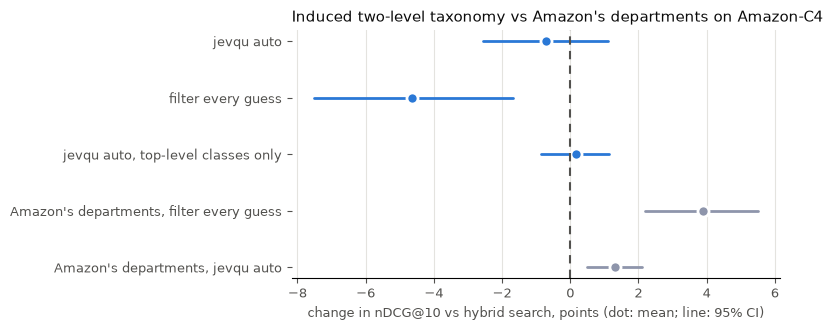

In [9]:
BLUE, INK, MUTED, GRID, GREY = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df", "#8e95ab"
names = list(results) + [f"Amazon's departments, {k}" for k in REFERENCE]
vals = [(v["change"], *v["ci"]) for v in results.values()] + list(REFERENCE.values())
fig, ax = plt.subplots(figsize=(8, 3.4))
ys = list(range(len(names)))[::-1]
for y, name, (d, lo, hi) in zip(ys, names, vals):
    color = GREY if name.startswith("Amazon") else BLUE
    ax.plot([100 * lo, 100 * hi], [y, y], color=color, lw=2, solid_capstyle="round")
    ax.plot(100 * d, y, "o", color=color, ms=8, markeredgecolor="white", markeredgewidth=2)
ax.axvline(0, color=MUTED, lw=1.5, ls=(0, (4, 3)))
ax.set_yticks(ys, names)
ax.set_xlabel("change in nDCG@10 vs hybrid search, points (dot: mean; line: 95% CI)", color=MUTED, fontsize=9)
ax.set_title("Induced two-level taxonomy vs Amazon's departments on Amazon-C4", loc="left", color=INK, fontsize=11)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## 6. What the induced classes look like

For each kept class (children under their parent): how many items Jev labeled with it, which Amazon departments those items come from, and three example items. Then how the queries used them.

In [10]:
members = defaultdict(list)
for d in catalog:
    for c in stored[pid[d["item_id"]]].get("classes") or []:
        members[c].append(d)
name_of = {c.id: c.name for c in tax.classes}
order = [c for p in sorted(level1, key=lambda c: -len(members[c.id])) for c in [p] + tax.children(p.id)]
rows = ["| class | parent | items | top Amazon departments | examples |", "|---|---|---|---|---|"]
for c in order:
    ds = members[c.id]
    top = ", ".join(f"{k} {n / max(1, len(ds)):.0%}" for k, n in Counter(d["category"] for d in ds).most_common(2))
    ex = "; ".join(title(d)[:45] for d in ds[:3])
    rows.append(f"| {'&nbsp;&nbsp;' if c.parent else ''}{c.name} | {name_of.get(c.parent, '')} | {len(ds):,} | {top} | {ex} |")
display(Markdown("\n".join(rows)))

top_q = [max(u.classes, key=lambda kv: kv[1]) if u.classes else (None, 0.0) for u in us]
hit = [p >= 0.6 for _, p in top_q]
print(f"queries with a class at P >= 0.6: {np.mean(hit):.0%}; at P >= 0.9: {np.mean([p >= 0.9 for _, p in top_q]):.0%}")
for i in [i for i, h in enumerate(hit) if h][:4]:
    cid, p = top_q[i]
    f = build_filter(us[i], tax, "auto")
    kept_target = cid in (stored[next(iter(relevant[i]))].get("classes") or [])
    print(f'\n"{qtexts[i][:110]}..."\n   top class: {name_of[cid]} (P={p:.2f}); '
          f"filter: {[c.match.value for c in f.must] if f else None}; target item has this class: {kept_target}")


| class | parent | items | top Amazon departments | examples |
|---|---|---|---|---|
| Soft |  | 3,815 | Home 24%, Clothing 24% | Emircey Adjustable Neck Pillows for Pain Reli; HQRP 2-pack Cut-to-fit Foam Filter for Air Co; TOONOW Faux Fur Blanket Twin Size 70x78, Ligh |
| &nbsp;&nbsp;Boys Girls | Soft | 327 | Clothing 39%, Toys 27% | Mingtex Macrame Toy Hammock - for Stuffed Ani; Imily Bela Girls Pullover Sweaters Kids Long ; plplaaobo Simulation Cat Simulation, Stuffed  |
| &nbsp;&nbsp;Bedding | Soft | 359 | Home 73%, Pet 13% | Emircey Adjustable Neck Pillows for Pain Reli; TOONOW Faux Fur Blanket Twin Size 70x78, Ligh; Linenspa 2 Inch Memory Foam Mattress Topper,  |
| Casual |  | 2,884 | Clothing 62%, Home 15% | Plentio C Shaped Side Table with Charging Sta; LORYERGO TV Tray - TV Table, Folding Table Tr; THE COLLECTION ROYAL Crossbody Bag for Women, |
| &nbsp;&nbsp;Furniture | Casual | 183 | Home 72%, Garden 22% | Plentio C Shaped Side Table with Charging Sta; LORYERGO TV Tray - TV Table, Folding Table Tr; NIOIIKIT 39 Small Storage Ottoman Bench, Tuft |
| &nbsp;&nbsp;Men | Casual | 521 | Clothing 87%, Sports 7% | DJM T-Shirt for Mens and Women Black X-Large; Go All Out Adult Bigfoot Sasquatch Embroidere; Feethit Mens Non Slip Walking Sneakers Lightw |
| &nbsp;&nbsp;Shirt | Casual | 488 | Clothing 87%, Sports 8% | DJM T-Shirt for Mens and Women Black X-Large; Faherty Men's Short Sleeve Heather Henley; Fairy Grunge Aesthetic Shirts Tops for Women  |
| Decoration |  | 2,866 | Home 41%, Clothing 11% | Alladinbox 17 Inch Window Silhouette Lighted ; HomeKaren Fall Wreaths for Front Door 22 Inch; AISITIN DIY Solar Water Pump Kit, Solar Power |
| &nbsp;&nbsp;Party Supplies | Decoration | 482 | Home 45%, Toys 12% | Renyqatt Cool LED Light Up Glasses - 7 Color ; GOOSH 5 Foot Length Halloween Inflatables Hal; MOWO Glitter Star Paper Confetti Wedding Part |
| &nbsp;&nbsp;Curtain | Decoration | 100 | Home 90%, Electronics 7% | Aurbhosa Fall Watercolor Pumpkin Shower Curta; Sheer Star Curtains 63 inch Long Light Grey W; Magnetic Curtain Tiebacks 2 Pack Curtain Hold |
| &nbsp;&nbsp;Sticker | Decoration | 227 | Tools 21%, Electronics 15% | Marble Paper Granite Gray/White Roll Kitchen ; Red Valkyrie Decal Kit for DJI Mavic 2/Zoom D; Connecticut Sightseeing Picture Sticker Cut O |
| &nbsp;&nbsp;Decor | Decoration | 2,210 | Home 53%, Tools 10% | Alladinbox 17 Inch Window Silhouette Lighted ; HomeKaren Fall Wreaths for Front Door 22 Inch; AISITIN DIY Solar Water Pump Kit, Solar Power |
| &nbsp;&nbsp;Wall Decor | Decoration | 501 | Home 62%, Tools 14% | Alladinbox 17 Inch Window Silhouette Lighted ; Mingtex Macrame Toy Hammock - for Stuffed Ani; NXHOME Black Oval Mirror for Bathroom, Matte  |
| &nbsp;&nbsp;Jewelry | Decoration | 387 | Clothing 74%, Arts 8% | Swarovski Millenia Crystal Jewelry Earring Co; Crown Awards Silver Crystal Baseball Rings, B; PinkSheep 18 Pairs Clip On Earrings for Littl |
| &nbsp;&nbsp;Christmas Decoration | Decoration | 268 | Home 73%, Tools 8% | Alladinbox 17 Inch Window Silhouette Lighted ; Ollny Christmas Lights Outdoor String Lights ; Red Co |
| &nbsp;&nbsp;Outdoor | Decoration | 374 | Garden 46%, Home 25% | Alladinbox 17 Inch Window Silhouette Lighted ; HomeKaren Fall Wreaths for Front Door 22 Inch; AISITIN DIY Solar Water Pump Kit, Solar Power |
| Protective |  | 2,343 | Cell 21%, Electronics 14% | Xinocy Cute Case for Nintendo Switch OLED 202; BodyGlide Foot Anti Blister Balm, 0.8oz &0.35; H.VERSAILTEX Stretch Dining Chair Covers Set  |
| &nbsp;&nbsp;Cover | Protective | 1,283 | Cell 32%, Electronics 20% | Xinocy Cute Case for Nintendo Switch OLED 202; H.VERSAILTEX Stretch Dining Chair Covers Set ; GeekShare 4PCS Cat Paw Shape Thumb Grip Caps, |
| Holds |  | 2,327 | Home 36%, Electronics 9% | Plentio C Shaped Side Table with Charging Sta; THE COLLECTION ROYAL Crossbody Bag for Women,; BingoHive Automatic Soda Can Organizer for Re |
| Replacement |  | 1,993 | Automotive 24%, Tools 16% | BuiltRight Industries Rear Seat Release for F; HQRP 2-pack Cut-to-fit Foam Filter for Air Co; HK-Part Fan for ASUS TUF FX505DT FX705DU FX70 |
| &nbsp;&nbsp;Car | Replacement | 150 | Automotive 91%, Electronics 4% | Marsauto DE3175 31mm LED Interior Dome Light ; Detroit Axle - Front Lower Ball Joints + Sway; SPEC-D TUNING Tail Lights Black Compatible wi |
| &nbsp;&nbsp;Battery | Replacement | 101 | Electronics 50%, Household 30% | ATC 11.1V 6-Cell Replacement Laptop Battery f; JCB Watch Battery (Standard Assortment) AG1 A; TREE.NB 14.4V 4000mAh Battery for HITACHI BSL |
| Book |  | 1,704 | Kindle 59%, Books 37% | Hearth & Cauldron: A Cozy Culinary Murder Mys; Strict Confidence (Rochester Trilogy Book 2); FRANCINE: A Novel |
| Kitchen |  | 1,684 | Home 61%, Food 14% | Tupperware 2 Quart 2 Liter Push Button Pitche; Silonn Countertop Ice Maker Machine, Portable; McCormick Gourmet Jamaican Jerk Seasoning, 2  |
| &nbsp;&nbsp;Container | Kitchen | 465 | Home 84%, Household 6% | Tupperware 2 Quart 2 Liter Push Button Pitche; BingoHive Automatic Soda Can Organizer for Re; TCP Global 32 Ounce (1000ml) Disposable Flexi |
| Natural |  | 1,465 | Household 19%, Care 16% | McCormick Gourmet Jamaican Jerk Seasoning, 2 ; 447 Colors - Premium Egyptian Cotton - Stitch; Vital Proteins Collagen Peptides Powder Suppl |
| &nbsp;&nbsp;Plant | Natural | 241 | Food 38%, Garden 33% | CARMEL ORGANICS Organic Ashwagandha Root Powd; 20 Stalks of 4 Inches Straight Lucky Bamboo; Dried Goji Berries (Wolfberry), 3 LB Bag |
| &nbsp;&nbsp;Food | Natural | 348 | Food 62%, Pet 18% | McCormick Gourmet Jamaican Jerk Seasoning, 2 ; Vital Proteins Collagen Peptides Powder Suppl; CARMEL ORGANICS Organic Ashwagandha Root Powd |
| Tool |  | 1,343 | Tools 24%, Home 22% | Tipcoo Car Vacuum Wireless Handheld Car Vacuu; 1250W Powerful Handheld Steam Cleaner with De; AstroAI Air Compressor Tire Inflator, Portabl |
| &nbsp;&nbsp;Brush | Tool | 120 | Care 43%, Pet 22% | Jobsite Boot Scrubber - Outdoor Shoe Scraper ; YEEPSYS Fingernail Scrub Brush,Two-sided Natu; REVLON One-Step Volumizer Enhanced 1.0 Hair D |
| Gift |  | 1,324 | Home 34%, Toys 15% | Renyqatt Cool LED Light Up Glasses - 7 Color ; Florino – Friendly Flower Vase Modern Home Dé; WESAPPINC 4Pack 3D Greeting cards Pop Up Holi |
| Storage |  | 1,158 | Home 38%, Electronics 12% | Tupperware 2 Quart 2 Liter Push Button Pitche; BingoHive Automatic Soda Can Organizer for Re; Champagne Stoppers by KLOVEO - Patented Seal  |
| &nbsp;&nbsp;Bag | Storage | 313 | Home 19%, Electronics 17% | Trunk Organizer with Cooler, Collapsible Trun; Insulated Cooler Backpack - Keeps 30 Cans Hot; SUITEDNOMAD Compression Packing Cubes Set,Ult |
| &nbsp;&nbsp;Holder | Storage | 678 | Home 37%, Office 9% | BingoHive Automatic Soda Can Organizer for Re; skiguard Ski Wall Storage Rack: Snowboard Wal; PC Gaming Headset Headphone Hook Holder Hange |
| Athletic |  | 1,117 | Clothing 48%, Sports 28% | Hyperflite Jawz Black Competition Dog Disc 8.; AFITNE Women's Bootcut Yoga Pants with Pocket; The Technique of Water Polo: A Text for Playe |
| Pet |  | 875 | Pet 93%, Sports 1% | Hyperflite Jawz Black Competition Dog Disc 8.; Rx Vitamins Feline Minerals - Mineral Powder ; Richell Straw mag Set Pink 6 Months~ |
| Toys |  | 867 | Toys 61%, Pet 15% | Hyperflite Jawz Black Competition Dog Disc 8.; Renyqatt Cool LED Light Up Glasses - 7 Color ; Bits and Pieces - 750 Piece Shaped Jigsaw Puz |
| Shoes |  | 767 | Clothing 92%, Pet 2% | EMU Australia Wrenlette Womens Slippers Sheep; rosyclo Women's Platform Ankle Boots Elasticl; Maybolury Kids Dinosaur Clogs Slippers Shoes, |
| Lighting |  | 653 | Tools 60%, Automotive 10% | Alladinbox 17 Inch Window Silhouette Lighted ; Battery Operated Wall Sconce, Wireless Wall L; LED Camping Lantern Rechargeable, Waterproof  |
| Delicious |  | 525 | Food 81%, Pet 7% | McCormick Gourmet Jamaican Jerk Seasoning, 2 ; Red Baron Deep Dish Singles 4 Cheese Pizza, 1; Dried Goji Berries (Wolfberry), 3 LB Bag |
| Hair |  | 488 | Care 88%, Clothing 4% | Ear and Nose Hair Trimmer Clipper - 2022 Prof; Carol's Daughter Born To Repair 60-Second Moi; Facial Hair Removal for Women Hair Remover Pe |
| Audio |  | 435 | Electronics 53%, Instruments 15% | Ep.#3.4 - Not The Hill We Die On (The Frontie; Timekettle M2 Language Translator Earbuds - S; LARKSOUND All-in-One 2.1 Sound Bar for TV, 36 |
| Skin |  | 390 | Care 69%, Household 8% | BodyGlide Foot Anti Blister Balm, 0.8oz &0.35; High-Performance Oil Blotting Sheets for Face; Dionis Goat Milk Skincare Lavender Blossom Sc |
| Supplement |  | 335 | Household 75%, Pet 8% | Vital Proteins Collagen Peptides Powder Suppl; Cardiovascular Research Ferritin Iron Supplem; Quest Nutrition Protein Powder, Vanilla Milks |
| Strips |  | 325 | Tools 14%, Care 12% | Power Strip Surge Protector 10Ft - Wall Mount; YETAIM Sleep Patches, 60 Deep Sleep Patches f; Hamletoff Magnetic Knife Holder for Wall no D |
| Music |  | 316 | Instruments 32%, Electronics 19% | Pedalboard, Wooden Guitar Effects Pedal Board; Moukey Karaoke Machine, PA System Woofer, Por; Frienda 40 Pieces Guitar Fingertip Protectors |
| Control Fit |  | 266 | Clothing 17%, Automotive 15% | AFITNE Women's Bootcut Yoga Pants with Pocket; GeekShare 4PCS Cat Paw Shape Thumb Grip Caps,; Universal Remote Control Fit for All Dynex LC |
| Makeup |  | 257 | Care 93%, Home 2% | High-Performance Oil Blotting Sheets for Face; WantGor Compact Mirror, 2 Pack Makeup Mirrors; Wall-Mounted Makeup Mirror 8 inch Bathroom Do |
| Game |  | 236 | Toys 46%, Games 23% | The Technique of Water Polo: A Text for Playe; Bits and Pieces - 750 Piece Shaped Jigsaw Puz; Mexican Train Dominoes To Go |
| Fragrance |  | 227 | Care 34%, Household 25% | Nickelodeon Icarly Cologne Spray, 1 Ounce; Airomé Gardenia Passive White Porcelain Diffu; The Two Face Of Tomorrow |
| Japanese Style |  | 222 | Home 21%, Toys 12% | Xinocy Cute Case for Nintendo Switch OLED 202; Shun Cutlery Premier 9” Bread Knife; Effortle; Chopsticks Reusable 4 Pairs Multicolor Stainl |
| Bed |  | 213 | Home 71%, Pet 23% | Linenspa 2 Inch Memory Foam Mattress Topper, ; Elephance 18 Inch Full Bed Frame with Storage; Awolf Cat Beds for Indoor Cats,24 Inch Round  |
| Cable |  | 202 | Electronics 63%, Tools 7% | J-Tech Digital 8K HDMI Cable 100ft (30m) Fibe; UGREEN USB B to USB C Printer Cable 6 FT, Nyl; 10ft Long Multi Charging Cable, 3 Color, Nylo |
| Dress |  | 190 | Clothing 87%, Pet 6% | Samefar Womens Ribbed Scoop Neck Sleeveless T; Baby Girl Tulle Dress,Toddler Flower Girl Dre; HOMEYEE Women's Chic V-Neck Lace Patchwork Fl |
| Pain Relief |  | 175 | Household 75%, Home 9% | Emircey Adjustable Neck Pillows for Pain Reli; Memory Foam Pillow for CPAP Side Sleeper, IKS; Florensi Back Roller - Back Stretcher, Back C |
| Mounting Bracket |  | 132 | Electronics 36%, Tools 15% | skiguard Ski Wall Storage Rack: Snowboard Wal; PC Gaming Headset Headphone Hook Holder Hange; Shower Curtain Rod Holder, Adhesive Shower Ro |
| Timepiece |  | 130 | Clothing 41%, Home 33% | SHARP AM/FM Clock Radio Alarm Clock, Wake to ; Timer, Timer for Kids, Kitchen Timer, Digital; ANGIEHAIE Tidsvenner Vintage Table Clock, Sil |
| Virtual |  | 110 | Games 40%, Kindle 29% | LEGO Batman 3: Beyond Gotham Batman Beyond Pa; Silent Hill 2; Xbox LIVE 12 Month Gold Membership Card |

queries with a class at P >= 0.6: 78%; at P >= 0.9: 52%

"I'm looking for a lightweight case that easily snaps onto my switch oled. It should have a design that doesn't..."
   top class: Protective (P=0.97); filter: ['protective', 'cover']; target item has this class: True

"I am searching for a perfect gift for a teen or tween girl between the ages of 8-14. I want a self-care gift t..."
   top class: Gift (P=0.96); filter: ['gift', 'hair']; target item has this class: False

"I need a product that properly aligns my spine while I sleep to relieve my bad back and neck muscles. I want t..."
   top class: Bedding (P=0.77); filter: None; target item has this class: True

"I need to find a new coffee maker that is worth splurging on. I want it to be so good that I'll never want to ..."
   top class: Kitchen (P=0.96); filter: ['kitchen']; target item has this class: True


In [11]:
out = {"classifier": JEV_MODEL if USE_JEV else "offline", "sample": SAMPLE, "k": K, "child_k": CHILD_K,
       "report": report, "classes": [dataclasses.asdict(c) for c in tax.classes],
       "baseline": {"ndcg10": float(np.mean(base_ndcg)), "recall20": float(np.mean(base_rec))},
       "results": results, "reference_departments": REFERENCE, "spent_usd": spent() if USE_JEV else 0.0}
(DATA / f"induction_results_k{K}_{CHILD_K}.json").write_text(json.dumps(out, indent=1, default=float))
print(f"saved data/c4/induction_results_k{K}_{CHILD_K}.json" + (f"; spent ${spent():.2f} on Jev in this notebook" if USE_JEV else ""))


saved data/c4/induction_results_k20_80.json; spent $3.30 on Jev in this notebook
